In [5]:
from google.colab import drive
import os # Import the os module

# Attempt to unmount first, in case of a corrupted state
if os.path.isdir('/content/drive'): # Check if the directory exists
    try:
        drive.flush_and_unmount()
        print('Drive unmounted successfully.')
    except ValueError: # Catch error if drive is not mounted
        print('Drive was not mounted or could not be unmounted.')
    except Exception as e:
        print(f'An unexpected error occurred during unmount: {e}')

# Now, try mounting with force_remount=True again
drive.mount('/content/drive', force_remount=True)

Drive unmounted successfully.
Mounted at /content/drive


In [6]:
# Define the base path for your Google Drive folder
# Make sure the folder 'cifar10_cnn_training' exists in your Google Drive
# If it doesn't exist, you'll need to create it manually or programmatically.
DRIVE_FOLDER_PATH = '/content/drive/MyDrive/cifar10_cnn_training'

# Create the directory in Google Drive if it doesn't exist
import os
os.makedirs(DRIVE_FOLDER_PATH, exist_ok=True)
print(f'Google Drive folder created/verified at: {DRIVE_FOLDER_PATH}')

Google Drive folder created/verified at: /content/drive/MyDrive/cifar10_cnn_training


In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Defining a transform to convert images to tensors
transform_no_norm = transforms.Compose([
    transforms.ToTensor(),
])

# Loading the training and test datasets without normalization yet
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_no_norm)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_no_norm)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Training set size: {len(trainset)}")
print(f"Test set size: {len(testset)}")


100%|██████████| 170M/170M [00:02<00:00, 73.4MB/s]


Training set size: 50000
Test set size: 10000


### Visualizing Sample Images

Let's visualize a 10x10 grid of sample images, with one row for each class.

/tmp/ipykernel_240/3466004872.py:33: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap


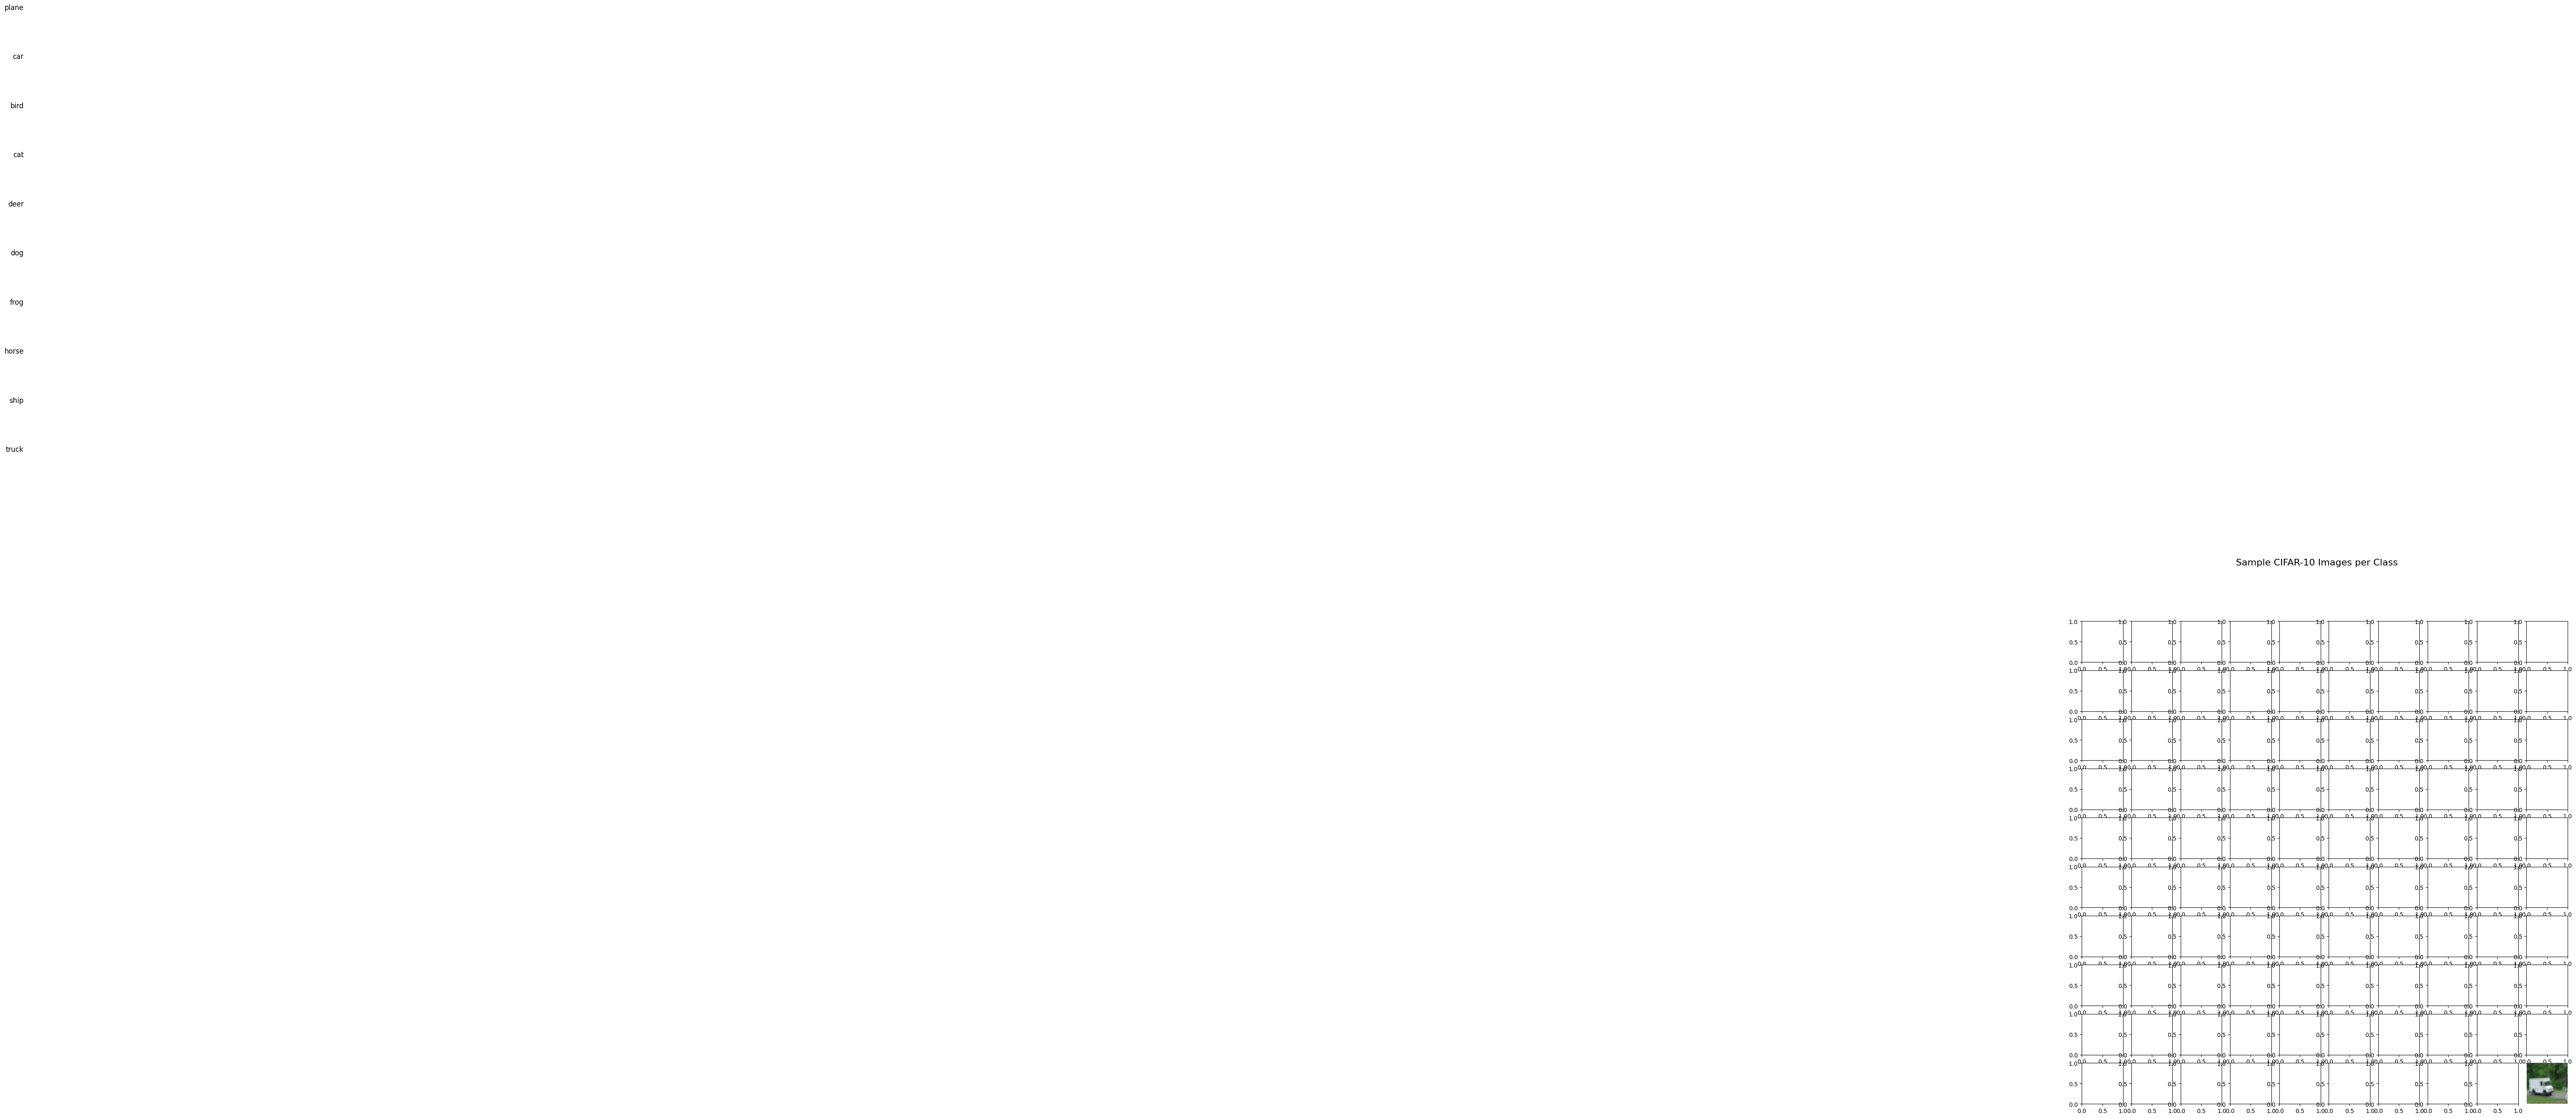

In [7]:
# Function to show an image
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off') # Hide axes

# Create a dictionary to store one image per class
class_images = {}
for i in range(len(trainset)):
    image, label = trainset[i]
    if label not in class_images:
        class_images[label] = image
    if len(class_images) == len(classes):
        break

# Plot 10x10 grid of sample images, one row per class
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
fig.suptitle('Sample CIFAR-10 Images per Class', fontsize=16)

for i, cls in enumerate(classes):
    # Find indices of images belonging to the current class
    class_indices = [j for j, (_, label) in enumerate(trainset) if label == i]
    # Select 10 random images from this class
    selected_indices = np.random.choice(class_indices, 10, replace=False)

    for j, idx in enumerate(selected_indices):
        img, _ = trainset[idx]
        ax = axes[i, j]
        imshow(img)
        if j == 0: # Add class label to the first image of each row
            ax.text(-50, 16, cls, va='center', ha='right', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()


### Analyzing Pixel Value Distributions

Mean pixel values (R, G, B): [0.491400808095932, 0.48215898871421814, 0.44653093814849854]
Standard deviation of pixel values (R, G, B): [0.2470276653766632, 0.24348346889019012, 0.2615877091884613]


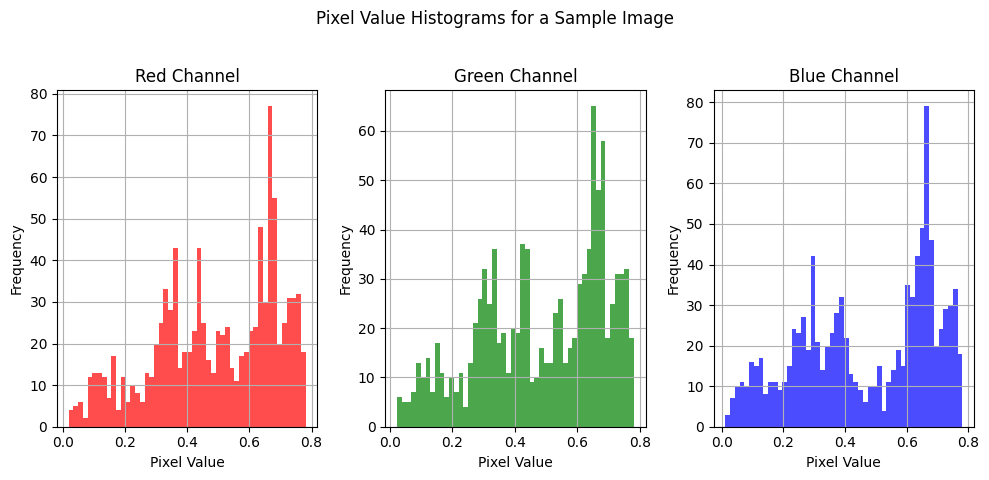

In [8]:
# Calculate mean and standard deviation for normalization
# We'll iterate through the training dataset to accumulate sums for mean and std

# Initialize sums for R, G, B channels
pixel_sum = torch.tensor([0.0, 0.0, 0.0])
pixel_sq_sum = torch.tensor([0.0, 0.0, 0.0])
num_pixels = 0

for inputs, _ in trainset:
    # inputs shape: (C, H, W)
    pixel_sum += inputs.sum(dim=[1, 2]) # Sum across H and W for each channel
    pixel_sq_sum += (inputs**2).sum(dim=[1, 2]) # Sum of squares across H and W for each channel
    num_pixels += inputs.shape[1] * inputs.shape[2] # H * W

mean = pixel_sum / num_pixels
std = torch.sqrt((pixel_sq_sum / num_pixels) - (mean**2))

print(f"Mean pixel values (R, G, B): {mean.tolist()}")
print(f"Standard deviation of pixel values (R, G, B): {std.tolist()}")

# Visualize pixel value distribution for a few random images (optional, as calculating for whole dataset is done above)
# Let's take a sample image and plot its histogram

sample_image, _ = trainset[np.random.randint(len(trainset))]

plt.figure(figsize=(10, 5))
plt.suptitle('Pixel Value Histograms for a Sample Image')

colors = ('red', 'green', 'blue')
for i, color in enumerate(colors):
    plt.subplot(1, 3, i + 1)
    plt.hist(sample_image[i].numpy().flatten(), bins=50, color=color, alpha=0.7)
    plt.title(f'{color.capitalize()} Channel')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Analyzing Class Balance

Training set class distribution:
Class plane: 5000 samples
Class car: 5000 samples
Class bird: 5000 samples
Class cat: 5000 samples
Class deer: 5000 samples
Class dog: 5000 samples
Class frog: 5000 samples
Class horse: 5000 samples
Class ship: 5000 samples
Class truck: 5000 samples


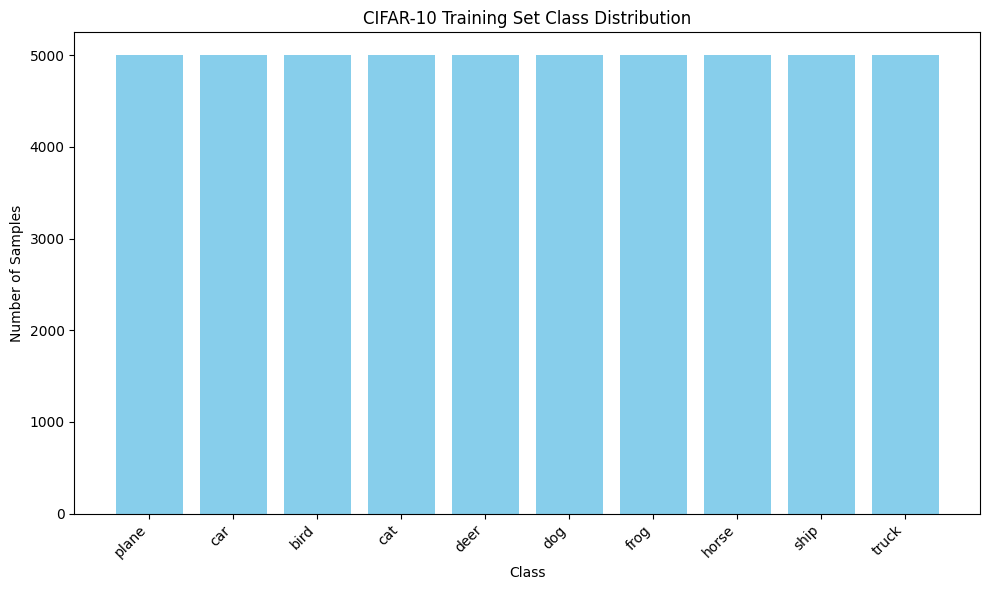


Test set class distribution:
Class plane: 1000 samples
Class car: 1000 samples
Class bird: 1000 samples
Class cat: 1000 samples
Class deer: 1000 samples
Class dog: 1000 samples
Class frog: 1000 samples
Class horse: 1000 samples
Class ship: 1000 samples
Class truck: 1000 samples


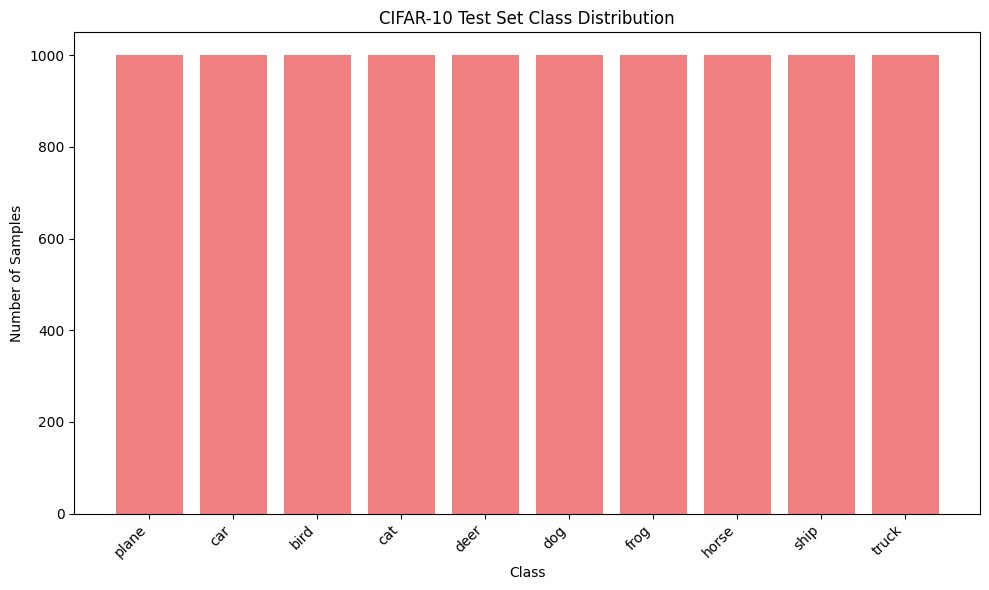

In [9]:
# Calculate class distribution for training set
train_labels = [label for _, label in trainset]
unique_train_labels, train_counts = np.unique(train_labels, return_counts=True)

print("Training set class distribution:")
for label, count in zip(unique_train_labels, train_counts):
    print(f"Class {classes[label]}: {count} samples")

# Plotting class distribution
plt.figure(figsize=(10, 6))
plt.bar(classes, train_counts, color='skyblue')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('CIFAR-10 Training Set Class Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Calculate class distribution for test set
test_labels = [label for _, label in testset]
unique_test_labels, test_counts = np.unique(test_labels, return_counts=True)

print("\nTest set class distribution:")
for label, count in zip(unique_test_labels, test_counts):
    print(f"Class {classes[label]}: {count} samples")

# Plotting test set class distribution
plt.figure(figsize=(10, 6))
plt.bar(classes, test_counts, color='lightcoral')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.title('CIFAR-10 Test Set Class Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Implementing Data Preprocessing and Augmentation

In [10]:
# Calculate mean and std for normalization based on the previous analysis
# Mean pixel values (R, G, B): [0.491400808095932, 0.48215898871421814, 0.44653093814849854]
# Standard deviation of pixel values (R, G, B): [0.2470276653766632, 0.24348345398902893, 0.2615877091884613]

# Define the transformation pipeline for training data with augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4), # Random crop with padding
    transforms.RandomHorizontalFlip(),    # Random horizontal flip
    transforms.RandomRotation(15),        # Random rotation by +/- 15 degrees
    transforms.ToTensor(),                # Convert images to PyTorch tensors
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)) # Normalize with calculated mean and std
])

# Define the transformation pipeline for test data (no augmentation, just normalization)
transform_test = transforms.Compose([
    transforms.ToTensor(),                # Convert images to PyTorch tensors
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)) # Normalize with calculated mean and std
])

# Load the training and test datasets with the new transforms
trainset_processed = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                download=True, transform=transform_train)
testset_processed = torchvision.datasets.CIFAR10(root='./data', train=False,
                                               download=True, transform=transform_test)

print("Data preprocessing and augmentation transforms defined and applied.")

# Note: One-hot encoding is typically handled by the loss function (e.g., CrossEntropyLoss)
# in PyTorch, which expects class indices, not one-hot vectors, for classification tasks.
# If one-hot encoding is strictly required for a different purpose, it would be applied to the labels separately.


Data preprocessing and augmentation transforms defined and applied.


### Creating Data Loaders

In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

# Create data loaders for training and test sets
trainloader = DataLoader(trainset_processed, batch_size=BATCH_SIZE,
                                          shuffle=True, num_workers=2)
testloader = DataLoader(testset_processed, batch_size=BATCH_SIZE,
                                         shuffle=False, num_workers=2)

print(f"Data loaders created with batch size: {BATCH_SIZE}")
print(f"Number of training batches: {len(trainloader)}")
print(f"Number of test batches: {len(testloader)}")

# Verify a batch shape
# For images, shape will be (batch_size, channels, height, width)
# For labels, shape will be (batch_size)
for images, labels in trainloader:
    print(f"Sample image batch shape: {images.shape}")
    print(f"Sample label batch shape: {labels.shape}")
    break


Data loaders created with batch size: 64
Number of training batches: 782
Number of test batches: 157
Sample image batch shape: torch.Size([64, 3, 32, 32])
Sample label batch shape: torch.Size([64])


### Part 2: Model Architecture Design

#### Task 2.1: Baseline CNN

In [12]:
import torch.nn as nn
import torch.nn.functional as F

# Define the Baseline CNN architecture
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        # First convolutional block
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # 3 input channels (RGB), 32 output channels, 3x3 kernel
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 32 input channels, 64 output channels, 3x3 kernel
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        # The input size to the first dense layer depends on the output size of the second MaxPool layer.
        # Input image size: 32x32
        # After conv1 (32x32) -> pool1 (16x16)
        # After conv2 (16x16) -> pool2 (8x8)
        # Output channels from conv2 is 64. So, 64 * 8 * 8 = 4096
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10) # 10 output classes for CIFAR-10

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8) # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        # Softmax is typically applied in the loss function (e.g., CrossEntropyLoss in PyTorch)
        # or explicitly for prediction probabilities. For now, we return logits.
        return x

print("Baseline CNN architecture defined.")


Baseline CNN architecture defined.


#### Task 2.3: Model Summary for Base Cnn

In [13]:
# Instantiate the BaselineCNN model
model = BaselineCNN()

# Print the model architecture
print("Baseline CNN Model Architecture:")
print(model)

# Calculate total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params}")

# Placeholder for visualizing feature maps (requires model training first)
# This will be addressed after the model is trained.

Baseline CNN Model Architecture:
BaselineCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Total trainable parameters: 545098


#### Task 2.2: Advanced CNN (Option A: Mini-VGGNet)

In [14]:
import torch.nn as nn
import torch.nn.functional as F

# Define the Mini-VGGNet architecture
class MiniVGGNet(nn.Module):
    def __init__(self):
        super(MiniVGGNet, self).__init__()

        # Block 1
        self.conv1_1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 2
        self.conv2_1 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Block 3
        self.conv3_1 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv3_2 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv3_3 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        # Input image size: 32x32
        # After pool1 (16x16)
        # After pool2 (8x8)
        # After pool3 (4x4)
        # Output channels from conv3_3 is 256. So, 256 * 4 * 4 = 4096
        self.fc1 = nn.Linear(256 * 4 * 4, 512)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 10) # 10 output classes for CIFAR-10

    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = self.pool1(x)

        # Block 2
        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        x = self.pool2(x)

        # Block 3
        x = F.relu(self.conv3_1(x))
        x = F.relu(self.conv3_2(x))
        x = F.relu(self.conv3_3(x))
        x = self.pool3(x)

        # Flatten
        x = x.view(-1, 256 * 4 * 4)

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)
        return x

print("Mini-VGGNet architecture defined.")


Mini-VGGNet architecture defined.


#### Task 2.3: Model Summary (Mini-VGGNet)

In [15]:
# Instantiate the MiniVGGNet model
model_mini_vgg = MiniVGGNet()

# Print the model architecture
print("Mini-VGGNet Model Architecture:")
print(model_mini_vgg)

# Calculate total trainable parameters
total_params_mini_vgg = sum(p.numel() for p in model_mini_vgg.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params_mini_vgg}")


Mini-VGGNet Model Architecture:
MiniVGGNet(
  (conv1_1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3_1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3_2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3_3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=51

### Visualizing Feature Maps from the First Convolutional Layer

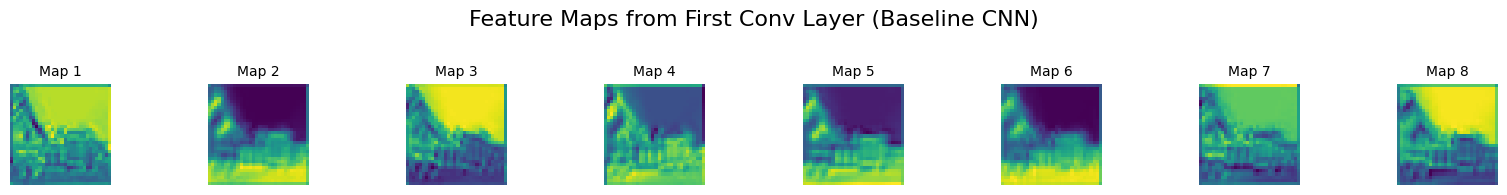

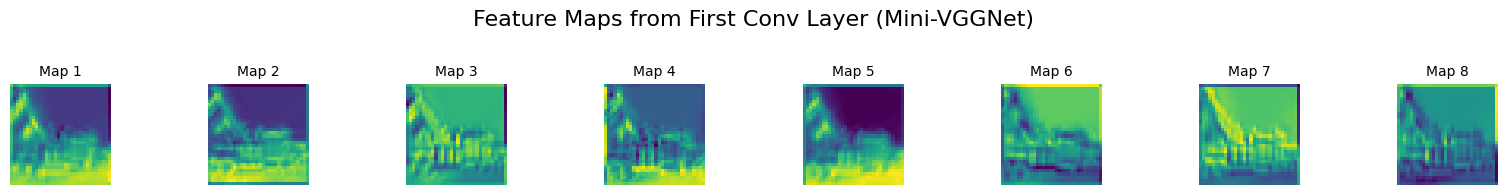

In [16]:
def visualize_feature_maps(model_name, model, layer, input_image, num_feature_maps=8):
    # Ensure the model is in evaluation mode
    model.eval()

    # Convert the input image to a batch (add a dimension for batch size)
    input_tensor = input_image.unsqueeze(0)

    # Get the output of the specified layer
    with torch.no_grad():
        # Dynamically get the layer output
        if isinstance(layer, nn.Conv2d):
            feature_maps = layer(input_tensor)
        else:
            # For more complex forward passes, we might need to modify the model's forward method
            # or register a forward hook. For the first conv layer, direct call is often possible.
            # Let's assume the first layer is directly accessible or its output can be captured.
            # For simplicity, we'll manually get the output for this specific task.
            if model_name == "Baseline CNN":
                feature_maps = model.conv1(input_tensor)
            elif model_name == "Mini-VGGNet":
                feature_maps = model.conv1_1(input_tensor) # First conv layer in Mini-VGGNet
            else:
                print(f"Warning: Model {model_name} not recognized for direct layer access.")
                return


    # Move feature maps to CPU and convert to numpy for plotting
    feature_maps = feature_maps.squeeze(0).cpu().numpy()

    # Determine how many feature maps to plot (up to num_feature_maps or total available)
    num_to_plot = min(feature_maps.shape[0], num_feature_maps)

    fig = plt.figure(figsize=(num_to_plot * 2, 2))
    fig.suptitle(f'Feature Maps from First Conv Layer ({model_name})', fontsize=16)

    for i in range(num_to_plot):
        ax = fig.add_subplot(1, num_to_plot, i + 1)
        ax.imshow(feature_maps[i], cmap='viridis') # Use a colormap suitable for activations
        ax.axis('off')
        ax.set_title(f'Map {i+1}', fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()

# Get a sample image from the test set
sample_image_processed, _ = testset_processed[np.random.randint(len(testset_processed))]

# Visualize for Baseline CNN (first conv layer is self.conv1)
visualize_feature_maps("Baseline CNN", model, model.conv1, sample_image_processed)

# Visualize for Mini-VGGNet (first conv layer is self.conv1_1)
visualize_feature_maps("Mini-VGGNet", model_mini_vgg, model_mini_vgg.conv1_1, sample_image_processed)


### Part 3: Training Strategy

In [17]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Instantiate the chosen model (e.g., BaselineCNN for now)
# We'll train both models eventually, but start with BaselineCNN for the setup.
model_to_train = BaselineCNN() # You can switch this to MiniVGGNet() later

# 1. Loss Function: Categorical cross-entropy
criterion = nn.CrossEntropyLoss()

# 2. Optimizer: Adam with L2 weight decay
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4 # L2 regularization
optimizer = optim.Adam(model_to_train.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# 3. Learning Rate Schedule: Reduce on plateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print("Loss function, optimizer, and learning rate scheduler initialized.")

Loss function, optimizer, and learning rate scheduler initialized.


#### Training Configuration

In [18]:
import os
import numpy as np
import json # Import json for saving history

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_to_train.to(device)

# Training Parameters
NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 15

# Update paths to save to Google Drive
MODEL_CHECKPOINT_PATH = os.path.join(DRIVE_FOLDER_PATH, 'best_model.pth')
ALL_CHECKPOINTS_DIR = os.path.join(DRIVE_FOLDER_PATH, 'all_model_checkpoints') # New directory for all checkpoints
HISTORY_FILE_PATH = os.path.join(DRIVE_FOLDER_PATH, 'training_history.json') # File to save training history

# Create directory for all checkpoints if it doesn't exist
os.makedirs(ALL_CHECKPOINTS_DIR, exist_ok=True)


# Initialize variables for early stopping and best model saving
best_val_loss = float('inf')
epochs_no_improve = 0

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'learning_rate': [], # To track LR changes
}

# Training function
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

# Evaluation function
def evaluate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

print("Training configuration and helper functions defined.")
print(f"Using device: {device}")

# Main training loop
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model_to_train, trainloader, criterion, optimizer, device)
    val_loss, val_acc = evaluate_epoch(model_to_train, testloader, criterion, device)

    scheduler.step(val_loss) # Adjust learning rate based on validation loss

    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['learning_rate'].append(current_lr) # Record current learning rate

    print(f'Epoch {epoch+1}/{NUM_EPOCHS}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, LR: {current_lr:.6f}')

    # Save checkpoint for current epoch
    epoch_checkpoint_path = os.path.join(ALL_CHECKPOINTS_DIR, f'model_epoch_{epoch+1}.pth')
    torch.save(model_to_train.state_dict(), epoch_checkpoint_path)
    print(f'Epoch {epoch+1} model checkpoint saved to {epoch_checkpoint_path}')

    # Model Checkpointing for best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model_to_train.state_dict(), MODEL_CHECKPOINT_PATH)
        print(f'Best model checkpoint saved at epoch {epoch+1} with validation loss: {best_val_loss:.4f}')
    else:
        epochs_no_improve += 1
        print(f'No improvement for {epochs_no_improve} epochs.')
        if epochs_no_improve == EARLY_STOPPING_PATIENCE:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

# Save training history to a JSON file at the end
training_metadata = {
    'hyperparameters': {
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'num_epochs': NUM_EPOCHS,
        'early_stopping_patience': EARLY_STOPPING_PATIENCE,
        'batch_size': BATCH_SIZE,
    },
    'history': history
}

with open(HISTORY_FILE_PATH, 'w') as f:
    json.dump(training_metadata, f, indent=4)
print(f'Training history and metadata saved to {HISTORY_FILE_PATH}')

print('Training complete!')

Training configuration and helper functions defined.
Using device: cpu
Epoch 1/50: Train Loss: 1.7487, Train Acc: 0.3545, Val Loss: 1.3602, Val Acc: 0.5100, LR: 0.001000
Epoch 1 model checkpoint saved to /content/drive/MyDrive/cifar10_cnn_training/all_model_checkpoints/model_epoch_1.pth
Best model checkpoint saved at epoch 1 with validation loss: 1.3602
Epoch 2/50: Train Loss: 1.5207, Train Acc: 0.4431, Val Loss: 1.2270, Val Acc: 0.5545, LR: 0.001000
Epoch 2 model checkpoint saved to /content/drive/MyDrive/cifar10_cnn_training/all_model_checkpoints/model_epoch_2.pth
Best model checkpoint saved at epoch 2 with validation loss: 1.2270
Epoch 3/50: Train Loss: 1.4229, Train Acc: 0.4825, Val Loss: 1.1463, Val Acc: 0.5870, LR: 0.001000
Epoch 3 model checkpoint saved to /content/drive/MyDrive/cifar10_cnn_training/all_model_checkpoints/model_epoch_3.pth
Best model checkpoint saved at epoch 3 with validation loss: 1.1463
Epoch 4/50: Train Loss: 1.3613, Train Acc: 0.5090, Val Loss: 1.0959, Val A

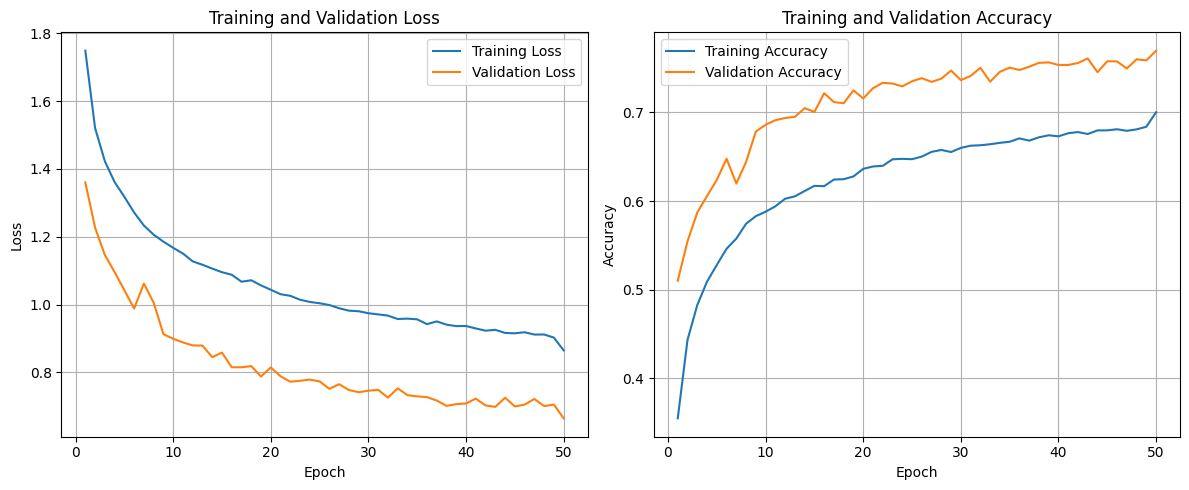

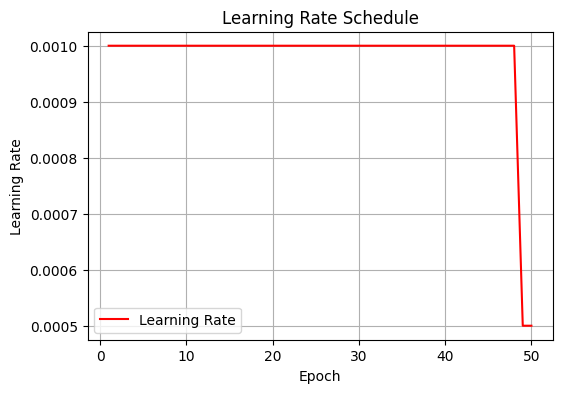

In [21]:
import matplotlib.pyplot as plt
import json

HISTORY_FILE_PATH = '/content/drive/MyDrive/cifar10_cnn_training/training_history.json'

# Load the training history from the JSON file
with open(HISTORY_FILE_PATH, 'r') as f:
    training_metadata = json.load(f)

history = training_metadata['history']

epochs = range(1, len(history['train_loss']) + 1)

# Plotting Training and Validation Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Training Loss')
plt.plot(epochs, history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting Training and Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='Training Accuracy')
plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Plotting Learning Rate
plt.figure(figsize=(6, 4))
plt.plot(epochs, history['learning_rate'], label='Learning Rate', color='red')
plt.title('Learning Rate Schedule')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.legend()
plt.grid(True)
plt.show()